# Étape 2 — Nettoyage

Entrée : `data/patients_nutrition.csv` (brut, 2500 lignes).
Sortie : `data/patients_nutrition_clean.csv`.

Périmètre : correction de type, traitement des valeurs manquantes colonne par colonne,
requalification des valeurs de saisie impossibles en valeurs manquantes puis imputation,
contrôle des bornes sur les autres colonnes. Aucune ligne n'est supprimée.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

raw = pd.read_csv("../data/patients_nutrition.csv")
df = raw.copy()
raw.shape


(2500, 15)

## 1. Correction de type

In [2]:
df["admission_date"] = pd.to_datetime(df["admission_date"])
df["admission_date"].dtype


dtype('<M8[us]')

## 2. `condition` — 25 valeurs manquantes

Le manque signifie « pathologie inconnue » ; il est distinct de la modalité `Aucune`
(pathologie connue comme absente). Requalification en modalité explicite `Non renseigné`.


In [3]:
print("Avant :")
print(df["condition"].value_counts(dropna=False))

df["condition"] = df["condition"].fillna("Non renseigné")

print("\nAprès :")
print(df["condition"].value_counts(dropna=False))


Avant :
condition
Aucune                 973
Diabète type 2         538
Hypertension           449
Obésité                348
Insuffisance rénale    167
NaN                     25
Name: count, dtype: int64

Après :
condition
Aucune                 973
Diabète type 2         538
Hypertension           449
Obésité                348
Insuffisance rénale    167
Non renseigné           25
Name: count, dtype: int64


## 3. Valeurs de saisie impossibles → valeurs manquantes

Distinction appliquée :
- **erreur de saisie** = valeur physiquement impossible (négative) ou incompatible avec
  toute alimentation (apport quasi nul) → requalifiée en `NaN`, puis imputée en section 5 ;
- **valeur extrême réelle** = rare mais atteignable → conservée (voir section 4).

Seuils : `daily_protein_g` < 5 g/j ; `daily_sodium_mg` < 100 mg/j.


In [4]:
protein_bad = df["daily_protein_g"] < 5
sodium_bad = df["daily_sodium_mg"] < 100

print("daily_protein_g < 5 g/j :", int(protein_bad.sum()))
print(raw.loc[protein_bad, ["patient_id", "diet_type", "daily_calories", "daily_protein_g"]])
print("\ndaily_sodium_mg < 100 mg/j :", int(sodium_bad.sum()))
print(raw.loc[sodium_bad, ["patient_id", "diet_type", "condition", "daily_sodium_mg"]])

df.loc[protein_bad, "daily_protein_g"] = np.nan
df.loc[sodium_bad, "daily_sodium_mg"] = np.nan


daily_protein_g < 5 g/j : 4
     patient_id      diet_type  daily_calories  daily_protein_g
210   PAT-00211  Hypocalorique          2266.0              1.6
519   PAT-00520     Diabétique          1883.0             -0.2
640   PAT-00641  Hypocalorique          1864.0              4.3
1088  PAT-01089  Hypocalorique          1873.0              1.5

daily_sodium_mg < 100 mg/j : 4
     patient_id      diet_type            condition  daily_sodium_mg
1439  PAT-01440       Standard       Diabète type 2           -142.0
1722  PAT-01723  Hypocalorique  Insuffisance rénale            -18.0
1774  PAT-01775  Hyperprotéiné               Aucune             71.0
1972  PAT-01973       Standard         Hypertension             94.0


## 4. Contrôle de plausibilité des `daily_sodium_mg` élevés

Vérification que les 20 valeurs > 5000 mg/j sont des valeurs réelles et non des erreurs
avant de décider de les garder.


In [5]:
s = df["daily_sodium_mg"].dropna().sort_values()
print("30 plus hautes valeurs de sodium (mg/j) :")
print(s.tail(30).round().tolist())
print()
print("Pas de rupture nette entre le corps de la distribution et la queue :")
print("p95 =", round(s.quantile(0.95)), " p99 =", round(s.quantile(0.99)), " max =", round(s.max()))

hi = df[df["daily_sodium_mg"] > 5000]
print("\nRépartition des", len(hi), "valeurs > 5000 mg/j :")
print(hi.groupby("diet_type").size())
print(hi.groupby("condition").size())


30 plus hautes valeurs de sodium (mg/j) :
[4882.0, 4895.0, 4909.0, 4910.0, 4930.0, 4944.0, 4954.0, 4966.0, 4967.0, 4998.0, 5060.0, 5073.0, 5086.0, 5089.0, 5137.0, 5141.0, 5176.0, 5184.0, 5214.0, 5279.0, 5370.0, 5409.0, 5507.0, 5538.0, 5586.0, 5743.0, 5873.0, 6047.0, 6078.0, 6405.0]

Pas de rupture nette entre le corps de la distribution et la queue :
p95 = 4246  p99 = 4950  max = 6405

Répartition des 20 valeurs > 5000 mg/j :
diet_type
Hyperprotéiné    1
Hypocalorique    6
Sans sel         4
Standard         9
dtype: int64
condition
Aucune                 9
Diabète type 2         4
Hypertension           5
Insuffisance rénale    1
Obésité                1
dtype: int64


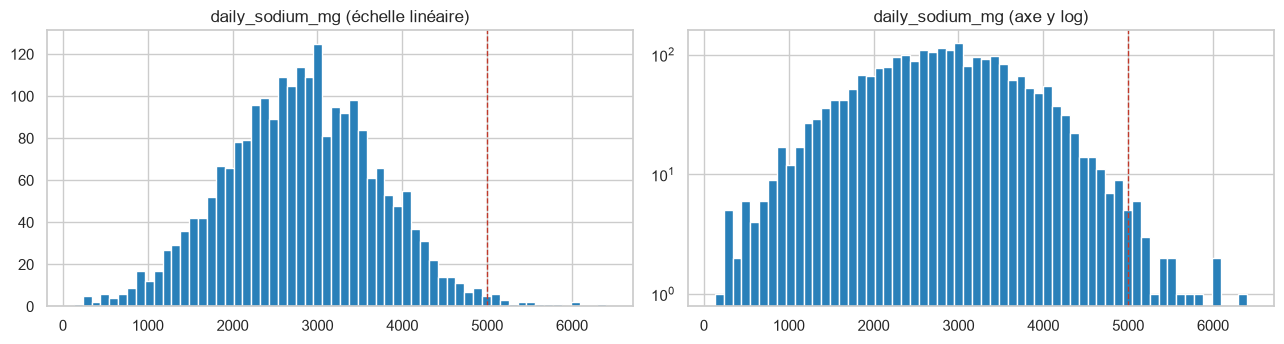

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
axes[0].hist(df["daily_sodium_mg"].dropna(), bins=60, color="#2980b9", edgecolor="white")
axes[0].set_title("daily_sodium_mg (échelle linéaire)")
axes[0].axvline(5000, color="#c0392b", ls="--", lw=1)
axes[1].hist(df["daily_sodium_mg"].dropna(), bins=60, color="#2980b9", edgecolor="white")
axes[1].set_yscale("log")
axes[1].set_title("daily_sodium_mg (axe y log)")
axes[1].axvline(5000, color="#c0392b", ls="--", lw=1)
plt.tight_layout()
plt.show()


Queue continue, sans discontinuité (pas de saut compatible avec une erreur d'unité ou
un facteur 10), valeurs consommables avec une alimentation très transformée, réparties
sur tous les régimes et pathologies. **Conservées telles quelles.**


## 5. Imputation des valeurs manquantes numériques

Trois colonnes : `daily_protein_g`, `daily_sodium_mg`, `weight_change_pct`.

Choix de la granularité de la médiane (globale vs par `diet_type`) décidé sur preuve :
test de Kruskal-Wallis des différences entre régimes, et corrélations avec les autres
variables numériques (pour une éventuelle imputation par modèle).


In [7]:
num_impute = ["daily_protein_g", "daily_sodium_mg", "weight_change_pct"]

by_diet = df.groupby("diet_type")[num_impute].median().round(2)
print("Médianes par diet_type :")
print(by_diet)
print("\nÉcart max entre régimes :")
print((by_diet.max() - by_diet.min()).round(2))

print("\nKruskal-Wallis (H0 : même distribution entre régimes) :")
for col in num_impute:
    groups = [g[col].dropna().values for _, g in df.groupby("diet_type")]
    print(f"  {col:20s} p = {stats.kruskal(*groups).pvalue:.2e}")

print("\nCorrélations avec les autres numériques :")
print(df[num_impute + ["age", "bmi", "daily_calories", "follow_up_weeks"]].corr()
        .loc[num_impute, ["age", "bmi", "daily_calories", "follow_up_weeks"]].round(3))


Médianes par diet_type :
               daily_protein_g  daily_sodium_mg  weight_change_pct
diet_type                                                         
Diabétique               66.80           2811.0              -0.04
Hyperprotéiné            65.80           2703.0              -0.92
Hypocalorique            65.50           2880.0              -1.92
Sans sel                 64.40           2845.5              -0.12
Standard                 64.85           2831.0              -0.02

Écart max entre régimes :
daily_protein_g        2.4
daily_sodium_mg      177.0
weight_change_pct      1.9
dtype: float64

Kruskal-Wallis (H0 : même distribution entre régimes) :
  daily_protein_g      p = 5.58e-01
  daily_sodium_mg      p = 3.06e-01
  weight_change_pct    p = 2.54e-34

Corrélations avec les autres numériques :
                     age    bmi  daily_calories  follow_up_weeks
daily_protein_g   -0.010 -0.001           0.019            0.018
daily_sodium_mg   -0.026  0.011          -0.0

`daily_protein_g` (p = 0,56) et `daily_sodium_mg` (p = 0,31) : aucune différence entre
régimes → **médiane globale**. `weight_change_pct` (p ≈ 3e-34) : forte différence
(le régime hypocalorique fait perdre plus de poids) → **médiane par `diet_type`**, pour
ne pas effacer cet effet sur les lignes imputées. Corrélations toutes ≈ 0 → imputation
par modèle (KNN, régression) sans intérêt.


In [8]:
before = df[num_impute].copy()

# médiane globale
for col in ["daily_protein_g", "daily_sodium_mg"]:
    df[col + "_imputed"] = df[col].isna()
    df[col] = df[col].fillna(df[col].median())

# médiane par diet_type
df["weight_change_pct_imputed"] = df["weight_change_pct"].isna()
df["weight_change_pct"] = df.groupby("diet_type")["weight_change_pct"].transform(
    lambda s: s.fillna(s.median())
)

print("Médianes globales :", df["daily_protein_g"].median().round(2),
      "g /", df["daily_sodium_mg"].median().round(0), "mg")
print("\nMédianes de weight_change_pct par diet_type utilisées pour l'imputation :")
print(before.assign(diet_type=df["diet_type"]).groupby("diet_type")["weight_change_pct"].median().round(2))
print("\nNombre de valeurs imputées par colonne :")
print(df[[c + "_imputed" for c in num_impute]].sum())


Médianes globales : 65.5 g / 2820.0 mg

Médianes de weight_change_pct par diet_type utilisées pour l'imputation :
diet_type
Diabétique      -0.04
Hyperprotéiné   -0.92
Hypocalorique   -1.92
Sans sel        -0.12
Standard        -0.02
Name: weight_change_pct, dtype: float64

Nombre de valeurs imputées par colonne :
daily_protein_g_imputed      104
daily_sodium_mg_imputed      154
weight_change_pct_imputed    225
dtype: int64


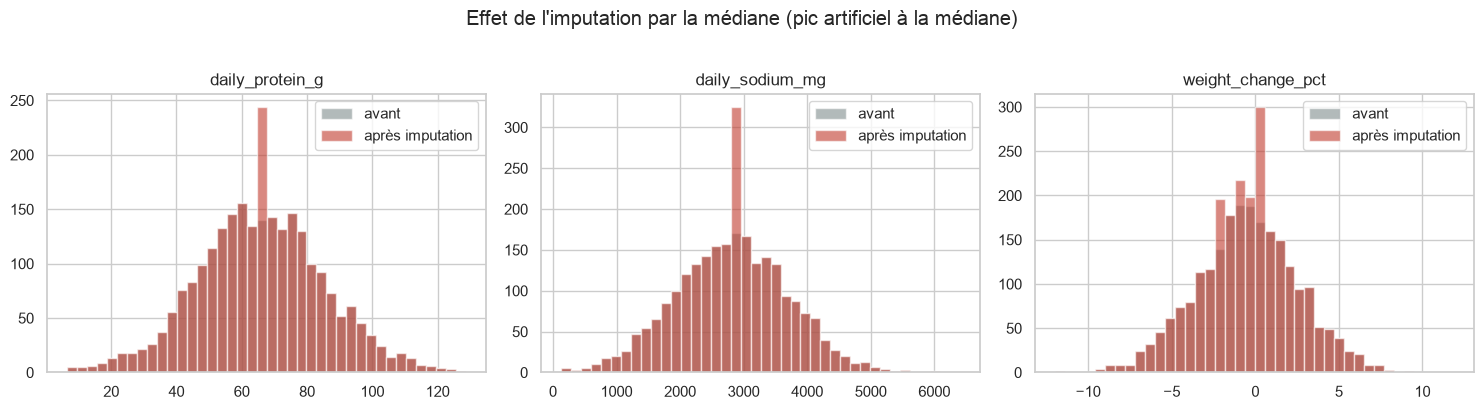

                    std_avant   std_apres  reduction_pct
daily_protein_g     19.733749   19.318787            2.1
daily_sodium_mg    903.546117  875.264466            3.1
weight_change_pct    3.102031    2.969121            4.3

weight_change_pct moyen par diet_type — effet préservé après imputation :
               avant  apres
Diabétique     0.089  0.078
Hyperprotéiné -0.936 -0.935
Hypocalorique -2.110 -2.089
Sans sel       0.167  0.155
Standard       0.083  0.073


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_impute):
    ax.hist(before[col].dropna(), bins=40, alpha=0.6, label="avant", color="#7f8c8d", edgecolor="white")
    ax.hist(df[col], bins=40, alpha=0.6, label="après imputation", color="#c0392b", edgecolor="white")
    ax.set_title(col)
    ax.legend()
fig.suptitle("Effet de l'imputation par la médiane (pic artificiel à la médiane)", y=1.02)
plt.tight_layout()
plt.show()

std_tbl = pd.DataFrame({
    "std_avant": before.std(),
    "std_apres": df[num_impute].std(),
}).assign(reduction_pct=lambda t: ((1 - t.std_apres / t.std_avant) * 100).round(1))
print(std_tbl)

print("\nweight_change_pct moyen par diet_type — effet préservé après imputation :")
print(pd.DataFrame({
    "avant": before.assign(d=df["diet_type"]).groupby("d")["weight_change_pct"].mean(),
    "apres": df.groupby("diet_type")["weight_change_pct"].mean(),
}).round(3))


## 6. Contrôle des bornes sur les autres colonnes

Colonnes de profil prioritaires (`age`, `bmi`, `daily_calories`) et les colonnes de
mesure restantes. On cherche des valeurs impossibles, pas des valeurs rares.


In [10]:
ranges = df[["age", "height_cm", "weight_kg", "bmi", "daily_calories",
             "follow_up_weeks", "nutritionist_visits"]].agg(["min", "max"]).T
ranges["commentaire"] = [
    "18-84 : plage adulte plausible",
    "145-200 : plausible",
    "40-100.3 : plausible",
    "15-36.6 : 15 = maigreur sevère mais réelle, pas d'impossibilité",
    "900-2978 : 900 = régime hypocalorique encadré, plausible",
    "1-25 semaines : plausible",
    "0-10 visites : plausible",
]
ranges


,min,max,commentaire
age,18.0,84.0,18-84 : plage adulte plausible
height_cm,145.0,200.0,145-200 : plausible
weight_kg,40.0,100.3,40-100.3 : plausible
bmi,15.0,36.6,"15-36.6 : 15 = maigreur sevère mais réelle, pa..."
daily_calories,900.0,2978.0,"900-2978 : 900 = régime hypocalorique encadré,..."
follow_up_weeks,1.0,25.0,1-25 semaines : plausible
nutritionist_visits,0.0,10.0,0-10 visites : plausible


In [11]:
print("Lignes entièrement dupliquées :", int(df.duplicated().sum()))
print("patient_id dupliqués :", int(df["patient_id"].duplicated().sum()))
print("age non entier / hors [18, 84] :", int(((df["age"] < 18) | (df["age"] > 84)).sum()))
print("bmi <= 0 :", int((df["bmi"] <= 0).sum()), " | daily_calories <= 0 :", int((df["daily_calories"] <= 0).sum()))


Lignes entièrement dupliquées : 0
patient_id dupliqués : 0
age non entier / hors [18, 84] : 0
bmi <= 0 : 0  | daily_calories <= 0 : 0


## 7. Validation finale

In [12]:
print("Valeurs manquantes restantes :")
print(df.isna().sum()[df.isna().sum() > 0] if df.isna().any().any() else "aucune")

print("\nDimensions :", df.shape, " (lignes conservées :", len(df) == len(raw), ")")
print("\nColonnes ajoutées :", [c for c in df.columns if c not in raw.columns])
print("\nTypes :")
print(df.dtypes)


Valeurs manquantes restantes :
aucune

Dimensions : (2500, 18)  (lignes conservées : True )

Colonnes ajoutées : ['daily_protein_g_imputed', 'daily_sodium_mg_imputed', 'weight_change_pct_imputed']

Types :
patient_id                              str
age                                   int64
gender                                  str
height_cm                           float64
weight_kg                           float64
bmi                                 float64
diet_type                               str
condition                               str
admission_date               datetime64[us]
daily_calories                      float64
daily_protein_g                     float64
daily_sodium_mg                     float64
follow_up_weeks                       int64
weight_change_pct                   float64
nutritionist_visits                   int64
daily_protein_g_imputed                bool
daily_sodium_mg_imputed                bool
weight_change_pct_imputed              bool
dt

In [13]:
df.to_csv("../data/patients_nutrition_clean.csv", index=False)
print("Écrit : data/patients_nutrition_clean.csv", df.shape)


Écrit : data/patients_nutrition_clean.csv (2500, 18)


## 8. Observations

- **Type** : `admission_date` converti en `datetime64`.
- **`condition`** : 25 manques → modalité `Non renseigné` (distincte de `Aucune`).
  Aucune ligne perdue.
- **Erreurs de saisie requalifiées en `NaN`** : `daily_protein_g` 4 valeurs < 5 g/j
  (dont 1 négative) ; `daily_sodium_mg` 4 valeurs < 100 mg/j (dont 2 négatives).
- **Valeurs extrêmes conservées** : 20 `daily_sodium_mg` > 5000 mg/j (max 6405).
  Queue de distribution continue, pas de signature d'erreur d'unité, valeurs atteignables.
- **Imputation** décidée sur test de Kruskal-Wallis (différences entre régimes) :
  - `daily_protein_g` (104 valeurs, p = 0,56) → médiane globale 65,5 g ;
  - `daily_sodium_mg` (154 valeurs, p = 0,31) → médiane globale 2820 mg ;
  - `weight_change_pct` (225 valeurs, p ≈ 3e-34) → médiane par `diet_type`
    (Hypocalorique −1,92 %, Hyperprotéiné −0,92 %, autres ≈ 0), pour préserver
    l'effet régime → perte de poids.
  Imputation par modèle (KNN, régression) écartée : corrélations avec les autres
  numériques toutes ≈ 0. Colonnes indicatrices `*_imputed` ajoutées ; réduction
  d'écart-type de 1 à 5 %.
- **Autres colonnes** : bornes contrôlées (`age`, `bmi`, `daily_calories`, `height_cm`,
  `weight_kg`, `follow_up_weeks`, `nutritionist_visits`) — aucune valeur impossible,
  aucune correction. Aucun doublon.
- **Sortie** : `data/patients_nutrition_clean.csv`, 2500 lignes × 18 colonnes
  (15 d'origine + 3 indicatrices), 0 valeur manquante.
